# Web Scraping Project – Books to Scrape

## Project Overview
This project demonstrates web scraping using Python. 
Book information such as title, price, and rating was collected from the Books to Scrape website.

## Tools Used
- Python
- Requests
- BeautifulSoup
- Pandas
- Matplotlib

## Project Steps
1. Connect to the website
2. Extract book details
3. Create a Pandas DataFrame
4. Clean the data
5. Save the data as CSV
6. Perform basic analysis
7. Create visualizations

## 1.Import Libraries

In [2]:
import requests
from bs4 import BeautifulSoup

url="https://books.toscrape.com/"

response=requests.get(url)

print(response.status_code)

200


## 2.Parse HTML Content

In [3]:
soup=BeautifulSoup(response.text,"html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [6]:
print(soup.find("article"))

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [7]:
book=soup.find("article")

print(book.h3.a["title"])

A Light in the Attic


In [8]:
price=book.find("p",class_="price_color").text

print(price)

Â£51.77


In [10]:
rating=book.find("p",class_="star-rating")["class"][1]

print(rating)

Three


In [11]:
books=soup.find_all("article")

print("Number of books",len(books))

Number of books 20


## 3.Extract Book Details

In [12]:
book_data=[]

for book in books:
    title=book.h3.a["title"]
    price=book.find("p",class_="price_color").text
    rating=book.find("p",class_="star-rating")["class"][1]

    book_data.append({

        "Title":title,
        "Price":price,
        "Rating":rating

    })

    print(book_data)
    

[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}, {'Title': 'Sharp Objects', 'Price': 'Â£47.82', 'Rating': 'Four'}]
[{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Title': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Title': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}, {'Title': 'Sharp Objects', 'Price': 'Â£47.82', 'Rating': 'Four'}, {'Title': 'Sapiens: A Brief

## 4.Create DataFrame

In [13]:
import pandas as pd

df=pd.DataFrame(book_data)

df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [17]:
print(df["Price"].head(10))

0    Â£51.77
1    Â£53.74
2    Â£50.10
3    Â£47.82
4    Â£54.23
5    Â£22.65
6    Â£33.34
7    Â£17.93
8    Â£22.60
9    Â£52.15
Name: Price, dtype: str


In [19]:
print(df["Rating"].unique())

<StringArray>
['Three', 'One', 'Four', 'Five', 'Two']
Length: 5, dtype: str


In [20]:
df.to_csv("books_data.csv",index=False)

In [21]:
print(df.shape)
print(df.isnull().sum())

(20, 3)
Title     0
Price     0
Rating    0
dtype: int64


In [23]:
print(df["Price"].dtype)

str


## 5.Data Cleaning

In [25]:
df["Price"]=df["Price"].str.replace("₤", "", regex=False)

In [27]:
print(df["Price"].head(10).tolist())

['Â£51.77', 'Â£53.74', 'Â£50.10', 'Â£47.82', 'Â£54.23', 'Â£22.65', 'Â£33.34', 'Â£17.93', 'Â£22.60', 'Â£52.15']


In [28]:
df["Price"]=df["Price"].str.replace("Â₤", "", regex=False)

In [29]:
print(df["Price"].head())

0    Â£51.77
1    Â£53.74
2    Â£50.10
3    Â£47.82
4    Â£54.23
Name: Price, dtype: str


In [30]:
df["Price"]=df["Price"].str.replace(r"[^0-9.]","",regex=True)

In [31]:
print(df["Price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: str


In [32]:
df["Price"]=df["Price"].astype(float)

In [33]:
print(df["Price"].dtype)

float64


## 6.Data Analysis

In [35]:
print("Average Price:",df["Price"].mean())
print("Minimum Price:",df["Price"].min())
print("Maximum Price:",df["Price"].max())

Average Price: 38.048500000000004
Minimum Price: 13.99
Maximum Price: 57.25


In [37]:
print(df["Rating"].dtype)

str


In [39]:
df["Rating"]=df["Rating"].str.extract(r"(\d+)")

In [40]:
print(df["Rating"].head())

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Rating, dtype: str


In [41]:
print(df["Rating"].tolist())

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [42]:
df["Rating"]=[item["Rating"] for item in book_data]

In [43]:
print(df["Rating"].head())

0    Three
1      One
2      One
3     Four
4     Five
Name: Rating, dtype: str


In [45]:
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

df["Rating"] = df["Rating"].map(rating_map)

In [46]:
print(df["Rating"].head())

0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64


In [47]:
print("Average Rating:", df["Rating"].mean())
print("Highest Rating:", df["Rating"].max())
print("Lowest Rating:", df["Rating"].min())

Average Rating: 2.85
Highest Rating: 5
Lowest Rating: 1


## 7.Data Visualization

### 7.1 Book Prices

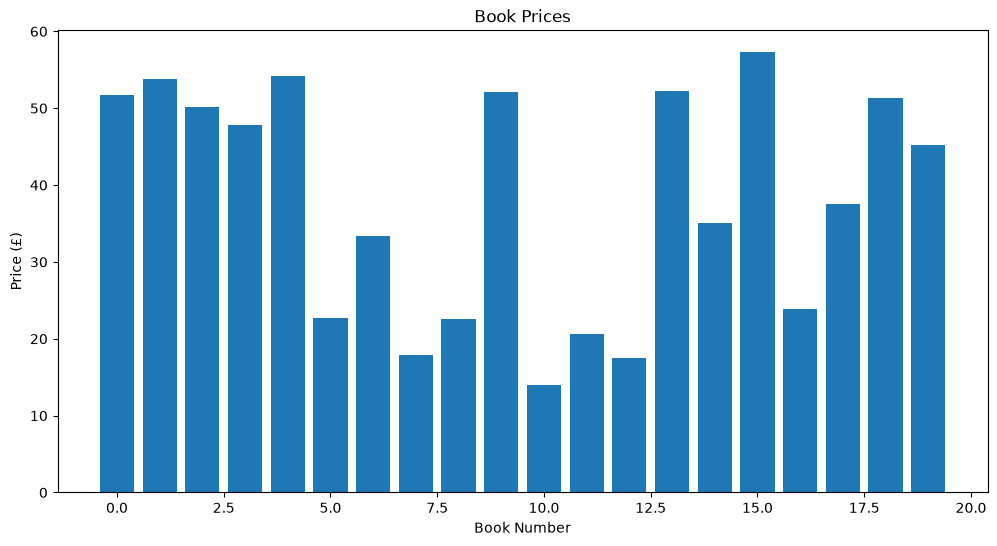

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(range(len(df)), df["Price"])

plt.xlabel("Book Number")
plt.ylabel("Price (£)")
plt.title("Book Prices")

plt.show()

### 7.2 Rating Distribution

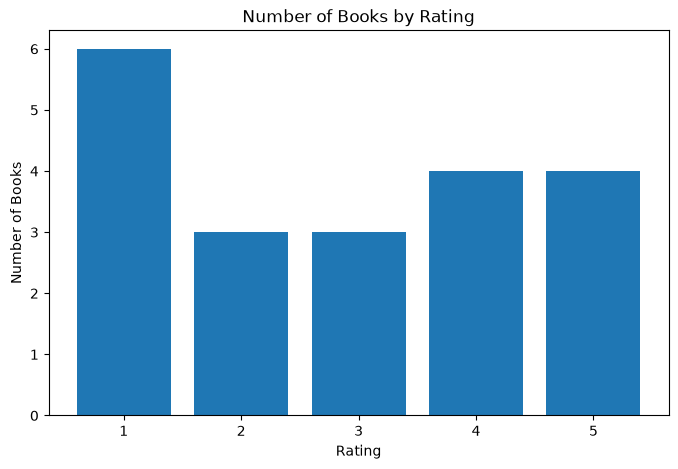

In [49]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating")

plt.show()

### 7.3 Price vs Rating

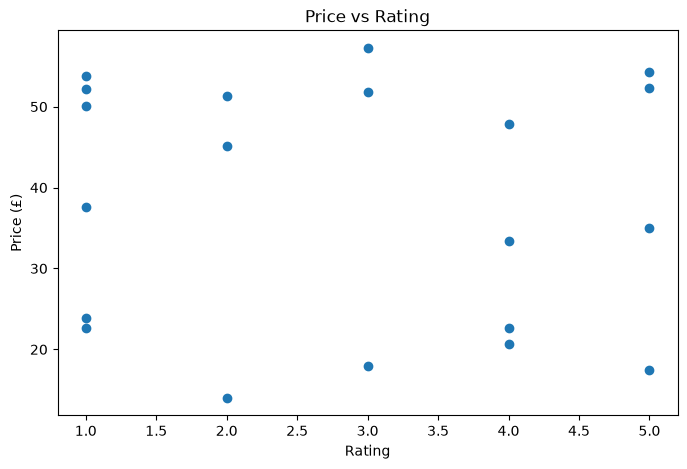

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Rating"], df["Price"])

plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.title("Price vs Rating")

plt.show()

## 8.Save Cleaned Dataset

In [51]:
df.to_csv("books_data_cleaned.csv", index=False)

In [52]:
print(df.head())

                                   Title  Price  Rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5


In [53]:
print("Rows and Columns:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (20, 3)

Missing Values:
Title     0
Price     0
Rating    0
dtype: int64

Data Types:
Title         str
Price     float64
Rating      int64
dtype: object


## 9. Conclusion

This project demonstrates how web scraping can be used to collect structured book data from a website.

The scraped data was cleaned and analyzed using Pandas, and visualizations were created using Matplotlib to understand book prices and ratings.

### Key Findings
- Book prices and ratings were successfully collected.
- The dataset contained 20 books with no missing values.
- Basic price and rating statistics were calculated.
- Visualizations helped compare prices and explore rating patterns.